# COGS 108 - EDA Checkpoint

## Authors

- Jeff Lin: Writing - original draft, Conceptualization
- Alena Lee: Project administration, Writing - review & editing
- Justin Suh: Experimental Investigation, Software, Analysis, Writing - original draft
- Steven Ngo: Experimental Investigation, Software, Data curation, Analysis
- Richard Wang: Software, Data curation, Visualization

# Research Question

Which genes, measured by gene expression on a 0-12 scale, contribute most to an accurate multiclass prediction of Luminal A, Luminal B, HER2-enriched, and Basal-like breast cancer subtypes, and are these gene contributions consistent across different classifiers?
- Which model performs best, and which genes are repeatedly presented as top predictors across gene feature choices?  


## Background and Prior Work

Breast cancer is a disease involving uncontrolled proliferation of cells resulting from DNA mutations acquired throughout a person’s lifetime. It is the most frequently diagnosed cancer, as well as one of the leading causes of death that is cancer-related. In 2026, an estimated 300,000+ cases of invasive breast cancer will be diagnosed, roughly translating to 1 in 8 women in the United States <a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1). One important thing to be aware of is that breast cancer isn’t one single disease. Tumors biologically are very different, which makes labeling them in subtypes a very useful labeling method. Gene expression profiling is a method that aims to distinguish cancerous from normal samples by analyzing individual, unique “molecular signatures” — specific patterns of genes that are switched on or off in cancer cells, but not in healthy tissue. In our question, we want to narrow down which genes contribute the most to specific types of breast cancer.

Each subtype of breast cancer primarily differs by the presence or absence of hormone receptors. These markers allow us to categorize tumors into four main molecular subtypes: Basal-like, HER2-enriched, Luminal A, and Luminal B. These four comprise our Kaggle dataset, and will be the types that we focus on within our analysis. In the clinic, each subtype is usually approximated using pathology tests – mainly: PR (progesterone receptor), ER (estrogen receptor), HER2 (human epidermal growth factor receptor 2), and other markers such as the nuclear protein Ki-67 (a familiar biomarker for cellular proliferation). As for the subtypes previously mentioned, they differ by a few main factors:

- Luminal A: Very hormone-driven with a lower proliferation rate. The typical receptors found are ER/PR+, HER2-, and low Ki-67. These factors indicate it is slower-growing and responds well to the hormone endocrine.
- Luminal B: Very hormone-driven; however, a higher proliferation rate than Luminal A. The typical receptors found are ER/PR+ (lower PR in comparison), and HER2 either +/-. These factors indicate more severity than Luminal A, and might need chemotherapy in addition to hormone therapy because it is less response to solely endocrine-based treatment 
- HER2-enriched: Driven primarily by the HER2 pathway, often HER2+, and is faster-growing and has a higher rate than Luminal A/B. Outcomes would improve with HER2-targeted treatments
- Basal-like: Triple negative with the common receptors ER/PR/HER2. Relies heavily on chemotherapy. 

The +/- sign following a receptor indicates the state of expression of that receptor for a certain tumor. For example, + means meaningful expression and that the receptor is turned on. 

Distinguishing the subtypes of cancer is critical in developing a treatment plan because it alters which hormone therapy should be applied to a patient. In HR+ circumstances, endocrine therapies are critical, whereas in HER2-driven cases, HER2-targeted drugs are of more importance. Furthermore, it changes the prognosis and recurrence pattern of a patient, since certain tumors have more favorable outlooks. 

After researching known information about what gene mutations cause/significantly increase the risk of developing breast cancer, we were able to narrow down hypotheses for each subtype of breast cancer. 

Previous research has explored a similar aspect in a published NlH article titled “Identification of breast cancer subtypes and drug response prediction through forward and reverse translation” <a name="cite_ref-3"></a>[<sup>3</sup>](#cite_note-3). In this study, they predicted subtype-specific therapeutic drug response by connecting patient tumor data with cancer screening data. This group trained NMF-based models on DepMap cell-line data in order to predict CDK4 vs CDK6 (classes of medicine used in combination with hormone therapy) dependency from gene expression and applied those models to TCGA tumors. Results from this test suggested that Luminal A was mostly skewed towards a CDK4 dependency, while Luminal B had a skewed CDK6 dependency. Additionally, some subtypes showed more hormone expression than others, such as those with higher estrogen-driven expression, and others with high cell-cycle programs. The core differences between this experimental model and our project are that they were more focused on using patterns across thousands of genes to discover and describe subgroups, whereas we want to determine which specific genes are the root cause of breast cancer subgroups to be expressed. 

Another study published in Science Direct takes a more similar approach to our project than the last, but focusing on using feature selection strategies to “identify statistically significant genes and accurately classify cancer types from RNA-seq data” <a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2). Essentially, this project aims to create a masterlist of what specific genes are found in cancer tumor tissue. This study is more similar to our project, but instead interested in a general view of cancer types, rather than solely focusing on breast cancer. Our project wants to create a link between named genes and a specific subgroup of breast cancer, rather than cancer as a whole. In the analysis, they utilized Ridge Regression and Lasso algorithms to find the best features from the data. With Ridge Regression, this method helped to identify dominant genes among their 800+ cancer tissue sample set (bound to have a lot of noise). It is a well-suited statistical method for high-dimensional genomic datasets. In contrast, Lasso serves as a regularization technique and is particularly useful when only a subset of features are informative. The results of this study created a refined list of the top ~100 genes that were associated with various tumor types. Furthermore, they were able to find the highest vs lowest expression of the top 50 genes with a distinction by color, expanding their conclusion to also consider co-expressed genes and condition-specific patterns <a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2). 

1. <a name="cite_note-1"></a> [^](#cite_ref-1) American Cancer Society. (2026, January 13). *Key statistics for breast cancer: How common is breast cancer?* Retrieved February 4, 2026, from https://www.cancer.org/cancer/types/breast-cancer/about/how-common-is-breast-cancer.html

3. <a name="cite_note-2"></a> [^](#cite_ref-2) Akter, S., Adesola, R. O., & Basnet, S. (2025). Machine learning approach to identify significant genes and classify cancer types from RNA-seq data. *Global Medical Genetics, 12*(4), 100079. https://doi.org/10.1016/j.gmg.2025.100079

4. <a name="cite_note-3"></a> [^](#cite_ref-3) Karam, J., Rejto, P. A., Bienkowska, J. R., Mu, X. J., & Roh, W. (2025). Identification of breast cancer subtypes and drug response prediction through forward and reverse translation. *NPJ Precision Oncology, 9*, Article 267. https://doi.org/10.1038/s41698-025-01062-w

# Hypothesis


We predict that Basal-like tumors will show higher KRT5 and KRT14 expression, quantified by a larger mean standardized expression (z-score) for KRT5/KRT14 in Basal-like samples compared to the other three subtypes, and that these genes will rank highly by model feature importance (e.g., large one-vs-rest coefficients on Logistic Regression Classification task, higher accuracy/F1 compared to other choices of genes). Likewise, we expect HER2-enriched to be driven by higher ERBB2/GRB7, Luminal A by higher ESR1/PGR with relatively low ERBB2, and Luminal B by higher ESR1 plus higher MKI67 than Luminal A. This is because the subtypes reflect differences in basal markers, HER2 signaling, hormone signaling, and proliferation.

## Data

### Data overview

In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [2]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
# datafiles = [
#     { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/airline-safety/airline-safety.csv', 'filename':'airline-safety.csv'},
#     { 'url': 'https://raw.githubusercontent.com/fivethirtyeight/data/refs/heads/master/bad-drivers/bad-drivers.csv', 'filename':'bad-drivers.csv'}
# ]

# get_data.get_raw(datafiles,destination_directory='data/00-raw/')

### Dataset #1 

Dataset Name: Breast cancer gene expression - CuMiDa
- Link to the dataset: https://www.kaggle.com/datasets/brunogrisci/breast-cancer-gene-expression-cumida
- Number of observations: 151 observations
- Number of variables: 54, 677 variables
- Description of the variables most relevant to this project: The most relevant variables include the normalized gene expression measurement and the breast cancer subtype label. The gene expression variables (Affymetrix ID) are continuous numerical features that represent the expression level of thousands of genes for each tumor sample. These will serve as the predictor variables in our classification model. The breast cancer subtype label is categorical and used to identify whether each sample is Basal-like, HER, Luminal A, or Luminal B, and acts as the response variable in our model. By combining these variables, they will allow us to train models and evaluate which specific genes contribute most to distinguishing between breast cancer subtypes.
- Descriptions of any shortcomings this dataset has with respect to the project: While the dataset is well-suited to our research question, it does present a few manageable limitations. To begin, the dataset contains a very large number of gene expression variables relative to the 151 samples, which means careful feature selection and model validation will be important to us to avoid overfitting. Additionally, the sample size is moderate, so we should keep in mind that the resulting findings should be interpreted as exploratory rather than definitive. There may also be some imbalance across subtype categories, which we can address by evaluating metrics such as precision, recall, and F1 score rather than relying solely on accuracy. The dataset also does not include demographic or clinical variables, so our analysis will focus strictly on molecular gene expression patterns rather than broader patient-level factors.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.manifold import TSNE

In [4]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION 
df_1 = pd.read_csv('data/02-processed/breast_cancer_gene_expression_processed.csv')
df_1.head()

,samples,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,84,basal,9.850040,8.097927,6.424728,7.353027,3.029122,6.880079,4.963740,4.408328,...,12.229711,11.852955,13.658701,13.477698,6.265781,5.016196,4.901594,2.966657,3.508495,3.301999
1,85,basal,9.861357,8.212222,7.062593,7.685578,3.149468,7.542283,5.129607,4.584418,...,12.178531,11.809408,13.750086,13.470146,6.771853,5.291005,5.405839,2.934763,3.687666,3.064299
2,87,basal,10.103478,8.936137,5.735970,7.687822,3.125931,6.562369,4.813449,4.425195,...,12.125108,11.725766,13.621732,13.295080,6.346952,5.171403,5.184286,2.847684,3.550597,3.158535
3,90,basal,9.756875,7.357148,6.479183,6.986624,3.181638,7.802344,5.490982,4.567956,...,12.111235,11.719215,13.743108,13.508861,6.610284,5.193356,5.086569,3.031602,3.524981,3.272665
4,91,basal,9.408330,7.746404,6.693980,7.333426,3.169923,7.610457,5.372469,4.424426,...,12.173642,11.861296,13.797774,13.542206,6.414354,5.040202,5.235318,2.956232,3.445501,3.193947


### Dataset #2
Dataset Name: GPL570 Annotation Table
- Link to the dataset: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GPL570 
- Number of observations: 54, 675 observations
- Number of variables: 16
- Description of the variables most relevant to this project: The two variables most relevant to this project are ID and Gene Symbol. The ID variable serves as the unique identifier for each row in the annotation table. Each ID is formatted as a string, representing an internal code made by the company Affymetrix. The second variable, Gene Symbol, is a human-readable name for the gene that each row refers to, such as “DDR1”, “RFC2”, and “HSPA6”. These Gene Symbols are formatted as strings and are the generic shorthands of the genes developed by scientists over time. The ID is going to be used as a key to retrieve the Gene Symbol, which will give our conclusion meaning, tying certain genes to certain subtypes of breast cancer.
- Descriptions of any shortcomings this dataset has with respect to the project: A majority of the variables in this dataset are unnecessary for our project. We’re only using this dataset to convert the IDs in the Kaggle dataset to their respective gene symbol counterpart in order to give an accurate conclusion as to what genes have the most impact on a model classifying breast cancer. It is also worth noting that some rows contain multiple genes separated by “///”, meaning a single probe ID corresponds to more than one gene. This introduces some ambiguity, as it might be difficult to determine which of these genes is the most relevant.

In [5]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION 
df_2 = pd.read_csv('data/02-processed/gpl570_annotation_processed.csv')
df_2.head(1)

C:\Users\jsuh0\AppData\Local\Temp\ipykernel_34256\1337864884.py:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2 = pd.read_csv('data/02-processed/gpl570_annotation_processed.csv')


,ID,GB_ACC,SPOT_ID,Species Scientific Name,Annotation Date,Sequence Type,Sequence Source,Target Description,Representative Public ID,Gene Title,Gene Symbol,ENTREZ_GENE_ID,RefSeq Transcript ID,Gene Ontology Biological Process,Gene Ontology Cellular Component,Gene Ontology Molecular Function
0,1007_s_at,U48705,NaN,Homo sapiens,"Oct 6, 2014",Exemplar sequence,Affymetrix Proprietary Database,U48705 /FEATURE=mRNA /DEFINITION=HSU48705 Huma...,U48705,discoidin domain receptor tyrosine kinase 1 //...,DDR1 /// MIR4640,780 /// 100616237,NM_001202521 /// NM_001202522 /// NM_001202523...,0001558 // regulation of cell growth // inferr...,0005576 // extracellular region // inferred fr...,0000166 // nucleotide binding // inferred from...


## Results

### Exploratory Data Analysis

We load the fully wrangled data from `data/02-processed` and perform four exploratory analyses to understand the structure of the breast cancer gene expression dataset before modeling. We examine highly expressed genes, correlations between the most variable genes, dimensionality reduction via PCA and t-SNE, and unsupervised clustering via K-Means. All analysis is performed on the filtered dataset containing only the four tumor subtypes: Basal-like, HER2-enriched, Luminal A, and Luminal B.

#### Principal Component Analysis (PCA)

We apply PCA to all gene expression features and reduce to 2 principal components to visualize whether the four subtypes naturally separate. Each point represents a tumor sample, colored by subtype. Clear separation in PCA space would suggest that gene expression patterns alone carry enough signal to distinguish subtypes before any classification model is applied.

In [6]:
# Select numeric columns only
numeric_data = df_1.select_dtypes(include=np.number).drop(columns=['samples'])
print("Original shape:", df_1.shape)
print("Numeric columns shape:", df_1.shape)

Original shape: (151, 54677)
Numeric columns shape: (151, 54677)


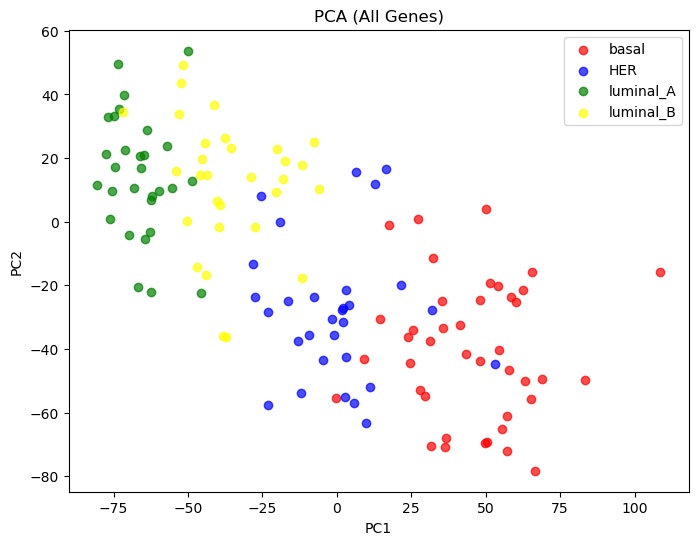

In [7]:
color_map = {'basal': 'red', 'HER': 'blue', 'luminal_A': 'green', 'luminal_B': 'yellow'}

pca = PCA(n_components=2)
pca_result = pca.fit_transform(numeric_data)

plt.figure(figsize=(8,6))
for subtype, color in color_map.items():
    mask = df_1['type'] == subtype
    plt.scatter(pca_result[mask, 0], pca_result[mask, 1],
                label=subtype, color=color, alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA (All Genes)')
plt.legend()
plt.show()

The PCA plot shows clear separation between the four subtypes along PC1 and PC2. Basal samples (red) cluster in the lower right, Luminal A (green) in the upper left, HER (blue) in the middle, and Luminal B (yellow) overlaps somewhat with both Luminal A and HER. The overlap between Luminal A and Luminal B is consistent with their biological similarity as both are hormone receptor positive subtypes that differ mainly in proliferation rate and HER2 status. Overall, the separation validates that gene expression is highly informative for subtype classification.

#### T-Stochastic Neighbor Embeddings (T-SNE)

T-SNE is a nonlinear dimensionality reduction technique that preserves local structure and often reveals tighter clusters than PCA. We first reduce to 50 principal components before running T-SNE to reduce noise and computation time.

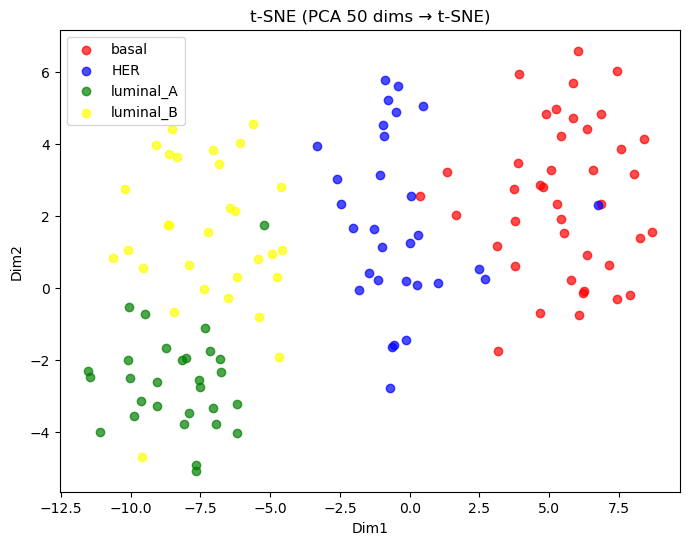

In [8]:
# reduce to 50 dims
pca_50 = PCA(n_components=50)
X_pca50 = pca_50.fit_transform(numeric_data)

# Then run t-SNE
tsne = TSNE()
X_embedded = tsne.fit_transform(X_pca50)

plt.figure(figsize=(8,6))
for subtype, color in color_map.items():
    mask = df_1['type'] == subtype
    plt.scatter(X_embedded[mask, 0], X_embedded[mask, 1],
                label=subtype, color=color, alpha=0.7)
plt.xlabel('Dim1')
plt.ylabel('Dim2')
plt.title('t-SNE (PCA 50 dims → t-SNE)')
plt.legend()
plt.show()

The T-SNE plot confirms the subtype separation seen in PCA, with even more distinct clusters. Basal (red) forms a cluster in the upper right. Luminal A (green) and Luminal B (yellow) are both in the left region but are still distinguishable. HER (blue) sits between the basal and luminal clusters. The cleaner separation in T-SNE compared to PCA further supports the feasibility of our classification approach.

#### Highly Expressed Genes EDA

C:\Users\jsuh0\AppData\Local\Temp\ipykernel_34256\2109989079.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genes.values, y=top_genes.index, palette="viridis")


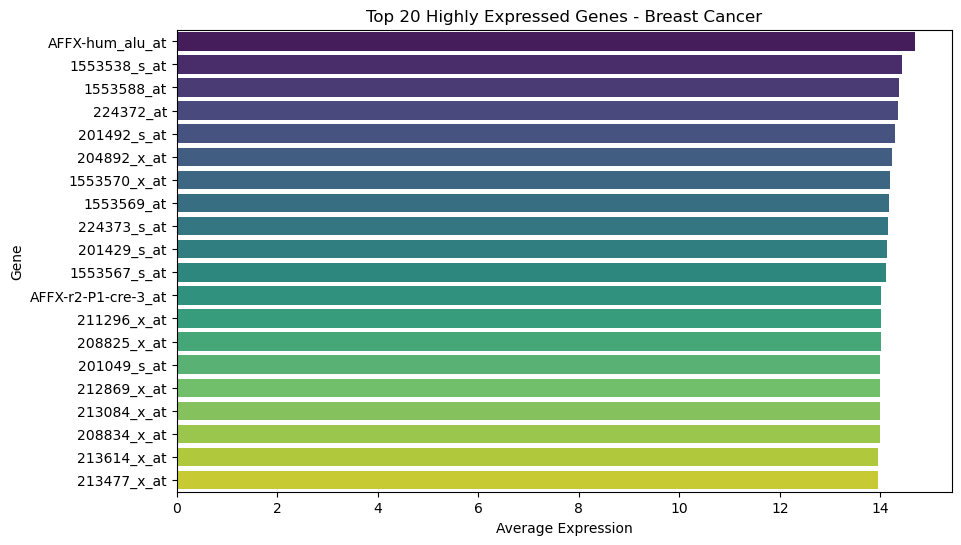

In [9]:
# Average expression per gene (numeric columns only)
avg_expression = numeric_data.mean(axis=0)
top_genes = avg_expression.sort_values(ascending=False).head(20)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x=top_genes.values, y=top_genes.index, palette="viridis")
plt.title("Top 20 Highly Expressed Genes - Breast Cancer")
plt.xlabel("Average Expression")
plt.ylabel("Gene")
plt.show()

This bar graph shows the top 20 most expressed genes for breast cancer, plotting their gene ID's vs. average expression. 

In [10]:
df_2['ID'] = df_2['ID'].str.strip()    
df_2.set_index('ID', inplace=True)

# [df_2[['ID']].apply(lambda col: col.str.contains('AFFX-hum', case=False)).any(axis=1)]

We use the GPL570 Dataset to extract the names of the top 3 genes for further research.

In [11]:
print(f"Top 3 Genes: \n{df_2.loc['1553538_s_at']['Gene Title']}, \n{df_2.loc['1553588_at']['Gene Title']}, \n{df_2.loc['224372_at']['Gene Title']}")
print(f"{df_2.loc['AFFX-hum_alu_at']['Gene Title']}")

Top 3 Genes: 
cytochrome c oxidase subunit I, 
NADH dehydrogenase, subunit 3 (complex I) /// SH3-domain kinase binding protein 1, 
NADH dehydrogenase, subunit 4 (complex I)
nan


**NADH dehydrogenase, subunit 4**:
A gene, abbreviated MT-ND4, which provides instructions for a protein called NADH dehydrogenase 4. Research shows that there is a significant relationship between the mutated MT-ND4 protein and the changes in structural conformation. This mutation plays an important role in developing breast cancer, making it helpful in detecting early stages of breast cancer.

**Cytochrome c oxidase subunit I**: 
Commonly abbreviated as COI, this is a vital protein-coding gene that is located in the mitochondrial genome. Dysfunction of this subunit can promote tumor aggression, and the disruption of COI can facilitate the metastasis and proliferation of breast cancer cells. As of right now, specific independent data of subunit I is less prominent; other subunits, such as COX5B and COX7AR, have been found to be upregulated in breast cancer. 

**NADH dehydrogenase, subunit 3 (complex I)**:
This gene is abbreviated as MT-ND3 and also encodes a crucial core subunit of mitochondrial complex I. Mutations as well as polymorphisms of this gene are associated with an increased risk of breast cancer (up to 75% in certain studies), and are suggested to be a marker of disease predisposition. With a high aggression factor, NADH dehydrogenase is highly relevant to the HER2-enriched and Luminal B subtypes of breast cancer. 

**AFFX-human_alu_at***: 
Not a gene, but a specific control probe set used on Affymetrix GeneChip microarrays, which monitor the quality of human sample preparation and hybridization. It serves as a positive control for the presence of human DNA/RNA in a sample.

> [!NOTE]
> **About subunits in NADH dehydrogenase**: 
NADH dehydrogenase is a large enzyme in the mitochondrial ETC, and is commonly referred to as Complex I. This enzyme plays a crucial role in cellular respiration, and is composed of multiple gene subunits which will be referred to later. Mutations of Complex I genes contribute to breast cancer because it impairs oxidative phosphorylation, leading to increased ROS (Reactive Oxygen Species) production. These metabolic shifts in the cell promote tumor growth and cell survival.

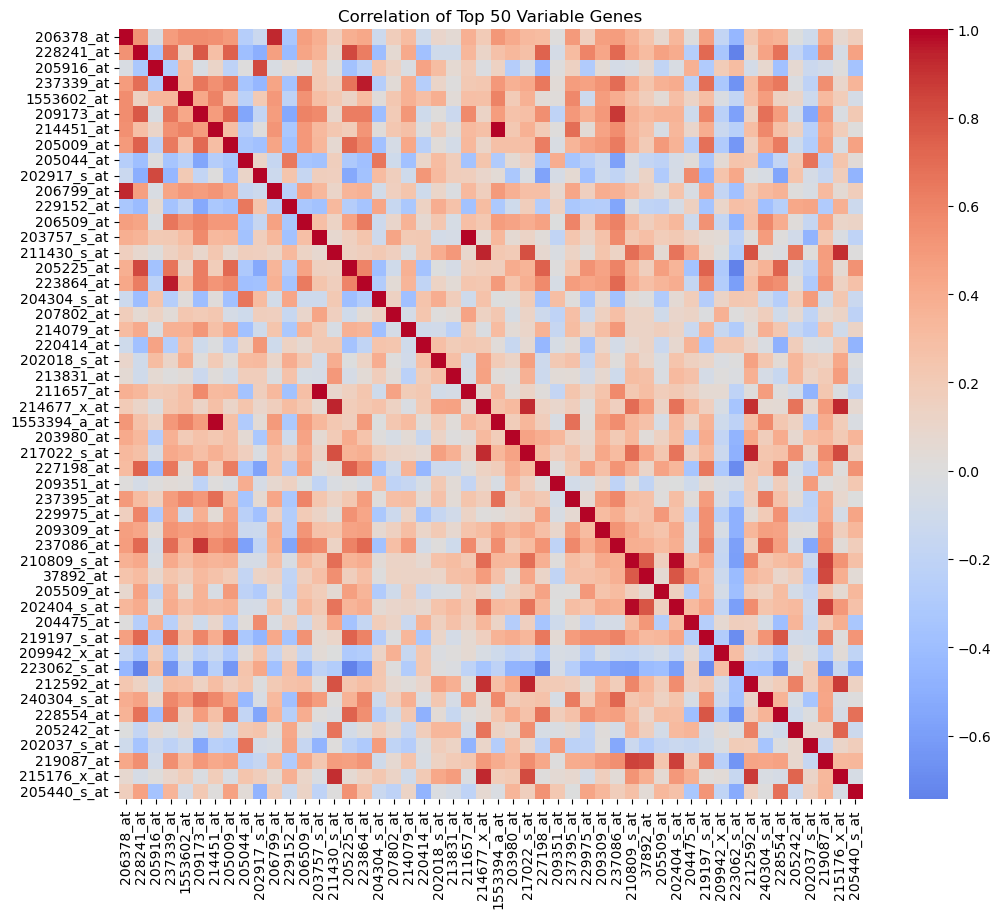

In [12]:
# Take top 50 most variable genes
top_var_genes = numeric_data.var().sort_values(ascending=False).head(50).index
subset_data = numeric_data[top_var_genes]

plt.figure(figsize=(12,10))
sns.heatmap(subset_data.corr(), cmap='coolwarm', center=0)
plt.title("Correlation of Top 50 Variable Genes")
plt.show()

There is some meaningful co-expression structure (some darker red patches indicating small co-expression modules possibly through related biological pathways), but not one giant uniform block. That means the top variable genes are not all redundant, though some are clearly related. This supports using PCA/clustering/feature selection, since there is enough correlation structure to reduce dimensionality.

#### PCA-Preprocessed K-Means Clustering (Top 100 Variable Genes)

Are we able to recluster 100-dimensional patient gene expressions on their principal components?

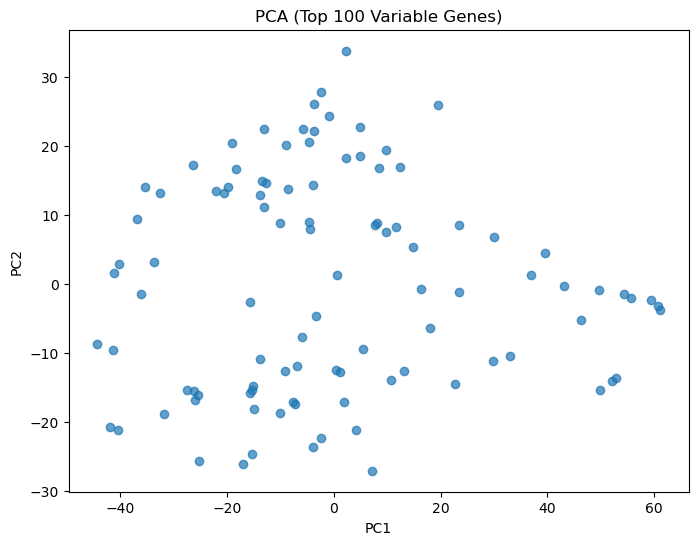

C:\Users\jsuh0\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


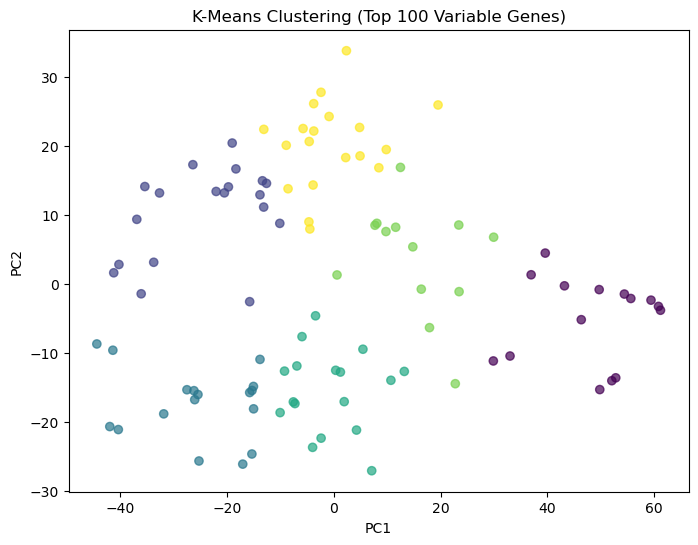

In [13]:
# Top 100 most variable genes
top_var_genes = numeric_data.var().sort_values(ascending=False).head(100).index
pca_data = numeric_data[top_var_genes].T  # Transpose so samples are rows

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(pca_data)

plt.figure(figsize=(8,6))
plt.scatter(pca_result[:,0], pca_result[:,1], alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA (Top 100 Variable Genes)')
plt.show()

# K-Means
kmeans = KMeans(n_clusters=6, random_state=42)
clusters = kmeans.fit_predict(pca_result)

plt.figure(figsize=(8,6))
plt.scatter(pca_result[:,0], pca_result[:,1], c=clusters, cmap='viridis', alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clustering (Top 100 Variable Genes)')
plt.show()


Selecting the top 100 most variable genes, we transpose the data so that rows = patients. We run PCA on 2 components to visualize and plot the projections of the 100-dimensional gene expression space. We then run K-Means clustering on the results. 

From this PCA plot, we can interpret that the data likely contains subtype structure; however, the first two PCs do not completely separate the samples by themselves. Some subtype information may be spread across more than two dimensions.

K-Means, however, finds coarse subgroupings, suggesting that subtype-related signal is likely present, and that these samples aren't just random noise, but contain patterns that naturally separate samples into broad groups. Biologically, these clusters may reflect major breast cancer subtype patterns (for example, a highly distinct HER2-like or basal-like group), but we would need to compare the cluster labels to the true known labels to know whether they correspond to actual subtypes in the next section.

#### Countplot

Types (6): ['HER', 'basal', 'cell_line', 'luminal_A', 'luminal_B', 'normal']


[Text(0.5, 1.0, 'Statistics of the different breast cancer types')]

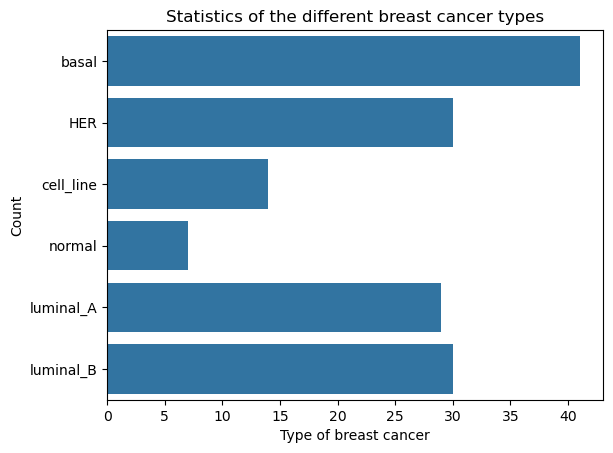

In [14]:
from itertools import chain

cancer_types = np.unique(list(chain(*df_1['type'].map(lambda x: x.split('|')).tolist())))
cancer_types = [x for x in cancer_types if len(x)>0]
print('Types ({}): {}'.format(len(cancer_types), cancer_types))

ax = sns.countplot(df_1['type'])
ax.set(ylabel = 'Count')
ax.set(xlabel = 'Type of breast cancer')
ax.set(title = 'Statistics of the different breast cancer types')

We implement a countplot over the types of breast cancer to visualize the dataset imbalances between each type. Most patients in our dataset have `basal`, while `HER` and `luminal_A/B` are moderate. Patients with `cell_line` and `normal` are the least represented, meaning we must account for dataset imbalances during prediction with weighted F1 metrics.

## Ethics

The dataset that we are using consists of gene expression data from breast tissue samples that were collected for research purposes and deposited in the publicly accessible Gene Expression Omnibus (GEO) database. The data is fully anonymized, meaning that there are no patient names, identifiers, medical histories, or demographic information attached to the samples. The dataset is publicly available for research and educational use, and we found no terms of use restrictions that would prohibit our analysis. However, we acknowledge several biases and limitations. The dataset consists of only 151 samples collected from a single study, which may not be representative of the global breast cancer population. We do not have information about the demographic backgrounds of the patients whose samples were used, so our findings may not generalize equally across different racial, ethnic, or age groups. The dataset also contains unequal sample sizes across subtypes, which could bias our model toward better performance on larger classes. To address these concerns, we will be transparent about these limitations when reporting our findings. Our analysis is purely educational and exploratory, and we do not intend for our findings to be used for medical diagnosis or treatment decisions.

[![Deon badge](https://img.shields.io/badge/ethics%20checklist-deon-brightgreen.svg?style=popout-square)](http://deon.drivendata.org/)


### A. Data Collection
- [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?


> The tissue samples were collected with consent for research purposes and deposited in the Gene Expression Omnibus (GEO), a publicly accessible database. 


- [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?


> The dataset was collected from a single study and lacks demographic information such as race, ethnicity, and age. This limits our ability to assess whether certain populations are underrepresented and whether our findings generalize across different groups. We likely won’t be able to take steps to address this, as the data was initially anonymized.


- [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?


> The dataset we chose already contains no personally identifiable information. The dataset only contains numerical gene expression values and cancer subtype labels.


- [ ] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?


### B. Data Storage
- [ ] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?
- [ ] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?
- [ ] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?


### C. Analysis
- [ ] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?
- [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, 
confirmation bias, imbalanced classes, or omitted confounding variables)?


> The dataset has some class imbalance, with some subtypes of breast cancer appearing more than others. This may lead to models performing better on larger classes. We will report per-class metrics and exclude cell line/normal samples as they may not accurately represent patient tumors.


- [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?


> All of the visualizations, summary statistics, and reports that we will create will be solely generated from the values in this dataset. We will clearly label sample sizes, report statistical significance where appropriate, and avoid making any claims that don’t correspond with our data.


- [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?


> Our initial dataset contains no PII. All analysis uses only anonymized gene expression values and subtype labels.


- [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?


> All code will be documented in Jupyter notebooks. The dataset is also publicly available, so our results should be easily reproducible.


### D. Modeling
- [ ] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?
- [ ] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?
- [ ] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?
- [ ] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?
- [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?


> Our analysis is purely educational and explanatory. We will clearly state that findings should not be used for clinical decision making without validation on larger, more diverse datasets.


### E. Deployment
- [ ] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?
- [ ] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?
- [ ] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
- [ ] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?

## Team Expectations 

Our main form of communication will be over iMessage. We believe this is the easiest way to get a hold of everyone by convenience. On most weekdays, we will reply within 36 hours.

Meetings: 2x/week (one planning meeting + one progress/check-in), 45–60 minutes, mostly virtual; in-person as needed.
Meeting norms: Come prepared with updates, blockers, and next steps. We’ll keep brief notes and action items after each meeting.

Tone & Collaboration Norms
- We commit to being respectful with our critique and assume feedback is well-meant.
- We will actively include quieter members (round-robin check-ins, asking for opinions directly, leaving space before moving on).

Decision-Making
- We aim for consensus, but if needed we’ll use a majority vote after discussion
- If an urgent decision is required and someone is non-responsive past the response window, the facilitator + section lead can decide and document it, then we revisit at the next meeting if needed.

Task Structure & Accountability
- We will use a shared Google docs with clear outlines of tasks and deliverables
- Roles can rotate, but we will assign clear owners for each deliverable (wrangling, EDA/viz, modeling, interpretation, writing/editing).

Everyone must contribute to:
- question/dataset decisions, code (wrangling/EDA/modeling), written narrative, and editing/review.
- Any code merged must be commented, readable, and reviewed by at least one teammate.

Planning & Deadlines
- We will maintain a living project timeline with internal deadlines at least 48–72 hours before course deadlines. This can be a bit flexible, as long as that is communicated.

When Someone Is Struggling
- If you’re stuck or falling behind, try to figure out the problem yourself, then tell the team if you are truly stuck (no later than 48 hours after realizing).
- The team will respond by: splitting the task and adjusting scope while preserving core requirements.

Conflict Resolution
- We will address issues early and respectfully: describe the problem, impact, and a proposed fix.
- If needed, we’ll revisit expectations and reassign tasks to match availability and strengths.

Dealing with Non-Participation
If someone repeatedly misses deadlines/meetings or is not contributing, we will: 
- notify them in written form with specific missing items and a clear 1-week improvement plan, redistribute tasks as needed to protect the project, and if there is no improvement, contact the professor (by Week 7 at the latest) with documented specifics.

## Project Timeline Proposal

## Outline

### Week 5 – Project Proposal
- We are proposing to use a high-dimensional dataset that may include advanced visualization and machine learning techniques not covered in this class. However, we believe that we have the ability to overcome most challenges in this project, and will happily use the resources given to us from the teaching staff.

### Week 6-7 – Data cleaning, wrangling and exploratory data analysis
- Inspect data, checking for missing values, potential confounding variables, normalize data
- Aggregate analysis (groupby operations)
- Perform left inner join on affymetrix gene dataset (ID column) to map uninterpretable feature names (affymetrix ID column names) from Kaggle/CuMiDa dataset to more interpretable feature values
    - Choose 1-2: Sequence Type, Target Description, Gene Title, Gene Symbol
    - Convert affymetrix gene dataset .txt file to .csv
    - Transpose one of the datasets (if necessary)
- OR look at affymetrix gene dataset and handpick/narrow down genes to use (filter)
- Perform visualization operations (dimensionality reduction via PCA/t-SNE/DBSCAN, line plots, scatter plots, box-plots, heatmaps)
    - Use seaborn (sns)
    - Explore different subproblems
    - Visualize different genes and clusters
    - Interpret variance of gene expressiveness and document early results

### Week 8 – Statistical Analysis
- Frame statistical question(s) and choose appropriate groups (distributions) of interest
- Perform statistical tests to compare sample vs. population or multiple groups
    - Tests include t-tests, ANOVA, etc.
- Revise hypothesis & background in accordance with feedback

### Week 9 – Feature Engineering, Predictive Modeling
- **Engineer new features if needed**
    - Nonlinear combinations (less interpretable)
    - Normalize data
    - Treat columns (genes) as vectors
- **Filter cancer types**
- **Dimensionality reduction**
- **Choose features and train classification models (multi-class) on different combinations of features**
- Interpret weights and biases, strength of metrics (accuracy, precision, recall)**
- Optimize bias-variance (Random Forests, NNs)
    - Visualize train-test accuracy over model complexity
- Handle class imbalances**

### Week 10 – Write Discussion, Additional Results, Finalize everything
- Build conclusions, interpret results
- Interpret column names (affymetrix IDs) to determine how our chosen genes may contribute most (or least) to breast cancer based on how much they are expressed in terms of their predictive power 
- Finalize ethics sections
- Finish discussion section
- Fix bugs and errors

### Finals Week – Video, Team Eval Survey


## Timeline Table

| Meeting Date | Meeting Time | Completed Before Meeting | Discuss at Meeting |
|---|---|---|---|
| 2/4 | 2 PM | NA | Edit, finalize, and submit proposal;<br>Search for datasets / confirm CuMiDa context;<br>Assign Week 6–7 tasks + set up workflow (repo, board, channels) |
| 2/9 | 2 PM | **Import & Wrangle Data (Justin, Steven, Richard; Reviewed by Alena, Jeff):** load data, check shape/labels, basic cleaning/formatting, inspect missingness/confounders;<br>**EDA (All):** class counts, initial PCA/t-SNE, basic distribution checks;<br>Locate Affymetrix annotation file + start `.txt → .csv` conversion | Review/edit wrangling + EDA outputs;<br>Finalize cleaning decisions (normalization, outliers, label handling);<br>Plan/confirm Affymetrix ID → gene mapping approach + which fields to keep;<br>Assign next visuals + early-writeup tasks |
| 2/16 | 2 PM | Finalize wrangling + EDA (cleaned dataset saved, mapped IDs or partial mapping);<br>Expanded visuals (PCA/t-SNE/heatmaps/boxplots) + brief interpretations;<br>**Begin Analysis (Alena, Jeff; Reviewed by TBD):** define statistical question(s), pick groups, draft test plan (t-test/ANOVA assumptions/alternatives) | Edit/approve final EDA + interpretations;<br>Confirm statistical tests + comparisons that answer the research question;<br>Decide Week 9 modeling plan (baseline models, CV, feature selection);<br>Progress check + rebalance tasks if needed |
| 2/23 | 2 PM | Run statistical analysis (tests + effect sizes + p-values, note multiple comparisons if needed);<br>Start modeling (baseline classifier(s), initial feature selection, first metrics);<br>**Draft Results/Discussion outline (Jeff, Alena; Reviewed by TBD):** section skeleton + figure placeholders | Review stats results for correctness + interpretation;<br>Debug modeling + discuss confusion points (e.g., luminal A vs B);<br>Choose final model(s) + tuning plan;<br>Assign writing owners (Methods/Results/Discussion/Ethics) + editing reviewers |
| 3/2 | 2 PM | Complete modeling + finalize figures (CV metrics, confusion matrix, macro-F1, performance vs complexity);<br>Finalize feature importance/top genes (if mapped);<br>**Draft Results/Conclusion/Discussion (All):** full draft + references + captions | Full-project edit session (clarity, structure, citations);<br>Connect findings to prior work + biology;<br>Finalize ethics section;<br>Identify remaining gaps/bugs + assign final polish + video plan |
| 3/9 | 2 PM | Full draft complete (all sections written, citations added, code cleaned/commented, figures finalized);<br>Video script/outline ready; peer-review pass completed | Final QA: run notebook top-to-bottom, fix bugs, rubric check;<br>Finalize video recording roles + timeline;<br>Confirm submission checklist + team eval expectations |
| 3/16 | Before EOD | NA | Turn in Final Project & Group Project Surveys |
